In [ ]:
import pandas as pd

In [ ]:
dados_clientes = pd.read_json('/content/TelecomX_Data.json')

In [ ]:
dados_clientes.to_csv('dados_clientes.csv', index=False)

In [ ]:
import pandas as pd
dados_clientes_normalizado = dados_clientes.copy()
nested_columns = ['customer', 'phone', 'internet', 'account']

for col in nested_columns:

    flattened_data = pd.json_normalize(dados_clientes[col])
    flattened_data.columns = [f'{col}_{sub_col}' for sub_col in flattened_data.columns]

    dados_clientes_normalizado = pd.concat([dados_clientes_normalizado, flattened_data], axis=1)

dados_clientes_normalizado = dados_clientes_normalizado.drop(columns=nested_columns)


print(dados_clientes_normalizado.head())

**Remoção de Colunas Irrelevantes**

In [ ]:
print(dados_clientes_normalizado.head())

**Encoding**

In [ ]:
import pandas as pd

categorical_cols = dados_clientes_normalizado.select_dtypes(include=['object']).columns
dados_clientes_normalizado = pd.get_dummies(dados_clientes_normalizado, columns=categorical_cols, drop_first=True)
print("Variáveis categóricas transformadas em formato numérico usando One-Hot Encoding.")
print(dados_clientes_normalizado.head())

**Verificação da Proporção de Evasão**

In [ ]:
total_clientes = len(dados_clientes_normalizado)
churn_yes_count = dados_clientes_normalizado['Churn_Yes'].sum()
churn_no_count = dados_clientes_normalizado['Churn_No'].sum()

proporcao_churn_yes = (churn_yes_count / total_clientes) * 100
proporcao_churn_no = (churn_no_count / total_clientes) * 100

print(f"Total de clientes: {total_clientes}")
print(f"Clientes que evadiram (Churn_Yes): {churn_yes_count} ({proporcao_churn_yes:.2f}%)")
print(f"Clientes que permaneceram ativos (Churn_No): {churn_no_count} ({proporcao_churn_no:.2f}%)")

if proporcao_churn_yes > 0 and proporcao_churn_no > 0:
    if abs(proporcao_churn_yes - proporcao_churn_no) > 20: # Arbitrary threshold for 'significant imbalance'
        print("Observa-se um desequilíbrio considerável entre as classes de churn e não-churn. Isso pode impactar o desempenho de modelos preditivos e pode ser necessário aplicar técnicas de reamostragem (oversampling, undersampling) ou ponderação de classes.")
    else:
        print("As classes de churn e não-churn estão relativamente equilibradas.")
else:
    print("Não foi possível calcular a proporção devido à ausência de uma ou ambas as classes de churn.")

**Balanceamento de Classes**

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

X = dados_clientes_normalizado.drop(columns=['Churn_Yes', 'Churn_No'])
y = dados_clientes_normalizado['Churn_Yes'] # 'Churn_Yes' representa a classe minoritária

print(f"Distribuição original da classe: {Counter(y)}")

# Aplicar SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print(f"Distribuição da classe após SMOTE: {Counter(y_res)}")

# Opcional: Recombinar em um DataFrame para futuras análises, se necessário
dados_clientes_balanceado = pd.concat([pd.DataFrame(X_res, columns=X.columns), pd.DataFrame(y_res, columns=['Churn_Yes'])], axis=1)


**Normalização ou Padronização**

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identificar as colunas numéricas a serem padronizadas
# Excluímos as colunas Churn_Yes e Churn_No (variável alvo) e as colunas booleanas já tratadas.

# Vamos identificar as colunas numéricas que não são resultado de one-hot encoding e não são a variável alvo
numerical_cols_to_scale = ['customer_tenure', 'account_Charges.Monthly']

# Instanciar o StandardScaler
scaler = StandardScaler()

# Criar uma cópia do DataFrame balanceado para evitar SettingWithCopyWarning
dados_clientes_balanceado_scaled = dados_clientes_balanceado.copy()

# Aplicar padronização nas colunas selecionadas
dados_clientes_balanceado_scaled[numerical_cols_to_scale] = scaler.fit_transform(dados_clientes_balanceado_scaled[numerical_cols_to_scale])

print("Colunas numéricas padronizadas com sucesso.")
print(dados_clientes_balanceado_scaled.head())

**Análise de Correlação**

Correlação das variáveis com 'Churn_Yes':
Churn_Yes                                       1.000000
account_PaymentMethod_Electronic check          0.439462
internet_InternetService_Fiber optic            0.350461
account_PaperlessBilling_Yes                    0.323803
account_Charges.Monthly                         0.229539
                                                  ...   
internet_InternetService_No                    -0.283551
internet_StreamingMovies_No internet service   -0.283551
internet_StreamingTV_No internet service       -0.283551
account_Contract_Two year                      -0.365611
customer_tenure                                -0.403399
Name: Churn_Yes, Length: 6560, dtype: float64


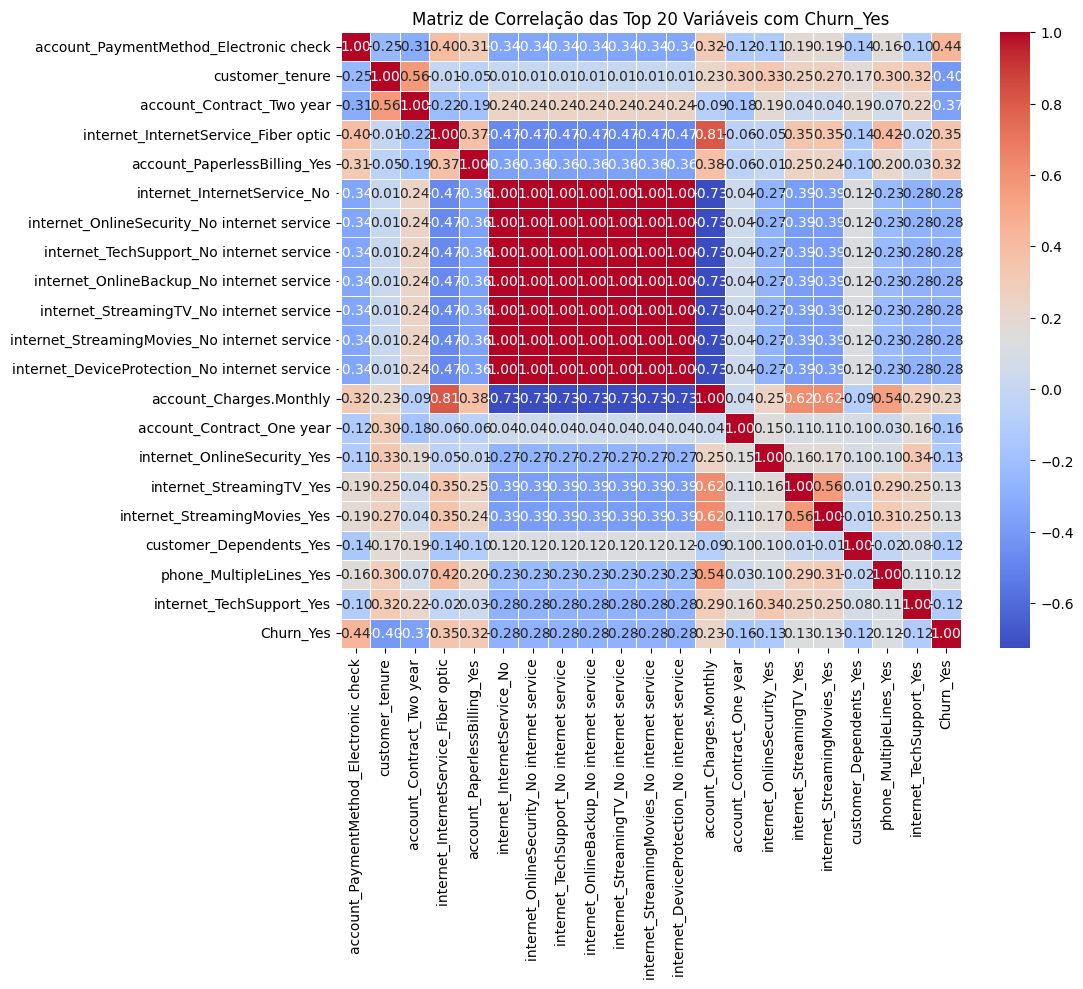

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular a matriz de correlação
correlation_matrix = dados_clientes_balanceado_scaled.corr()

# Filtrar as correlações com a variável alvo 'Churn_Yes'
# Ordenar para ver as maiores correlações primeiro
churn_correlation = correlation_matrix['Churn_Yes'].sort_values(ascending=False)

print("Correlação das variáveis com 'Churn_Yes':")
print(churn_correlation)

# Visualizar a matriz de correlação completa se necessário, mas para muitas colunas, focar em 'Churn_Yes' é melhor
# Para uma visão geral das correlações mais fortes, podemos pegar as top N ou um subset

# Gerar um heatmap apenas das correlações com 'Churn_Yes' ou de um subset de variáveis importantes
plt.figure(figsize=(10, 8))
# Pegar as 20 variáveis com maior correlação absoluta com Churn_Yes
top_correlated_features = churn_correlation.abs().sort_values(ascending=False).index[1:21] # Excluir Churn_Yes em si

# Criar um sub-dataframe apenas com essas features e Churn_Yes
subset_df = dados_clientes_balanceado_scaled[top_correlated_features.tolist() + ['Churn_Yes']]
subset_correlation_matrix = subset_df.corr()

sns.heatmap(subset_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Top 20 Variáveis com Churn_Yes')
plt.show()

**Análises Direcionadas**

In [ ]:
# Converte a coluna 'account_Charges.Total' para tipo numérico
# O parâmetro errors='coerce' transformará quaisquer valores não numéricos em NaN
dados_clientes_normalizado['account_Charges.Total'] = pd.to_numeric(dados_clientes_normalizado['account_Charges.Total'], errors='coerce')

# Verifica e preenche valores NaN resultantes da conversão
# Para 'Total Gasto', preencher com 0 pode ser uma abordagem razoável para clientes sem custo registrado, ou a mediana.
# Vamos verificar a quantidade de NaNs primeiro.
nan_count_total_charges = dados_clientes_normalizado['account_Charges.Total'].isnull().sum()

if nan_count_total_charges > 0:
    print(f"Encontrados {nan_count_total_charges} valores NaN na coluna 'account_Charges.Total'. Preenchendo com 0.")
    dados_clientes_normalizado['account_Charges.Total'].fillna(0, inplace=True)
else:
    print("Nenhum valor NaN encontrado na coluna 'account_Charges.Total' após a conversão.")

print("Coluna 'account_Charges.Total' convertida para tipo numérico e NaNs tratados com sucesso.")
print(dados_clientes_normalizado[['account_Charges.Total']].head())
print(dados_clientes_normalizado[['account_Charges.Total']].info())

**Separação de Dados**

In [ ]:
from sklearn.model_selection import train_test_split

# Separar as features (X) da variável alvo (y)
X = dados_clientes_balanceado_scaled.drop(columns=['Churn_Yes'])
y = dados_clientes_balanceado_scaled['Churn_Yes']

# Dividir o conjunto de dados em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Proporção de Churn no treino: {y_train.sum() / len(y_train):.2f}")
print(f"Proporção de Churn no teste: {y_test.sum() / len(y_test):.2f}")

Tamanho do conjunto de treino (X_train): (7557, 6559)
Tamanho do conjunto de teste (X_test): (3239, 6559)
Proporção de Churn no treino: 0.50
Proporção de Churn no teste: 0.50


**Criação de Modelos**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--------------------------------------------------")
print("Treinando e avaliando o modelo de Regressão Logística")
print("--------------------------------------------------")

# 1. Regressão Logística (modelo que exige normalização)
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)

print(f"Acurácia (Regressão Logística): {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Relatório de Classificação (Regressão Logística):")
print(classification_report(y_test, y_pred_log_reg))

print("\n--------------------------------------------------")
print("Treinando e avaliando o modelo de Random Forest")
print("--------------------------------------------------")

# 2. Random Forest (modelo que não exige normalização)
# Para Random Forest, podemos usar os dados normalizados também, mas não é estritamente necessário para o algoritmo funcionar.
# No entanto, como já temos X_train e X_test normalizados de passos anteriores, continuaremos com eles.
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)

y_pred_random_forest = random_forest_model.predict(X_test)

print(f"Acurácia (Random Forest): {accuracy_score(y_test, y_pred_random_forest):.4f}")
print("Relatório de Classificação (Random Forest):")
print(classification_report(y_test, y_pred_random_forest))

--------------------------------------------------
Treinando e avaliando o modelo de Regressão Logística
--------------------------------------------------
Acurácia (Regressão Logística): 0.8642
Relatório de Classificação (Regressão Logística):
              precision    recall  f1-score   support

       False       0.88      0.85      0.86      1620
        True       0.85      0.88      0.87      1619

    accuracy                           0.86      3239
   macro avg       0.86      0.86      0.86      3239
weighted avg       0.86      0.86      0.86      3239


--------------------------------------------------
Treinando e avaliando o modelo de Random Forest
--------------------------------------------------
Acurácia (Random Forest): 0.8679
Relatório de Classificação (Random Forest):
              precision    recall  f1-score   support

       False       0.88      0.86      0.87      1620
        True       0.86      0.88      0.87      1619

    accuracy                        

**Avaliação dos Modelos**


--------------------------------------------------
Matriz de Confusão para Regressão Logística
--------------------------------------------------


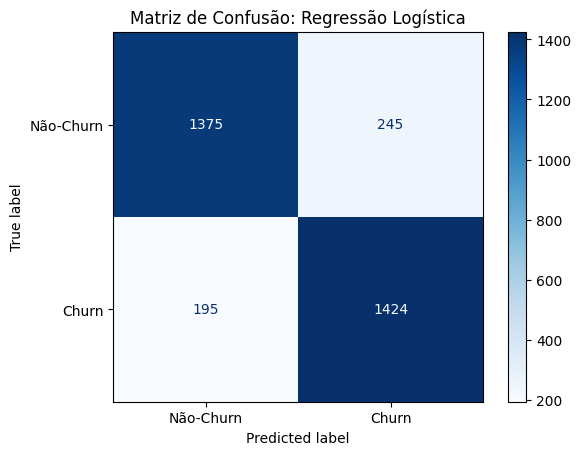


--------------------------------------------------
Matriz de Confusão para Random Forest
--------------------------------------------------


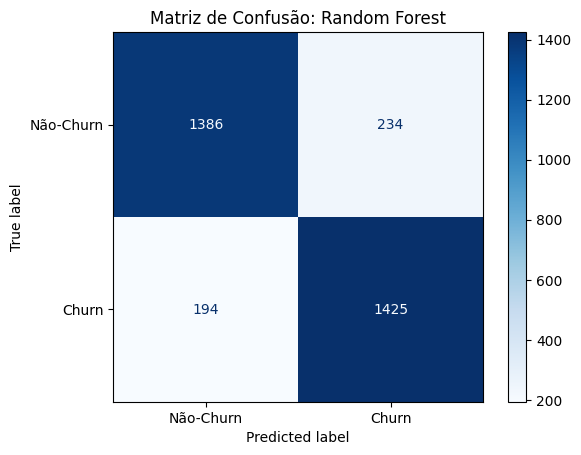


--------------------------------------------------
Análise Crítica e Comparação dos Modelos
--------------------------------------------------

Ambos os modelos, Regressão Logística e Random Forest, apresentaram um desempenho muito similar e robusto nas métricas avaliadas.

**1. Comparação de Desempenho:**
   - **Acurácia:** Random Forest (0.8679) teve uma acurácia ligeiramente superior à Regressão Logística (0.8642). A diferença é mínima, indicando que ambos classificam corretamente a maioria das instâncias.
   - **Precision, Recall e F1-score:** Ambos os modelos mostraram um bom equilíbrio entre Precision e Recall para ambas as classes (Churn e Não-Churn). O Random Forest apresentou valores marginalmente melhores, especialmente no F1-score para a classe 'True' (Churn), o que é importante para identificar corretamente os clientes que evadem.
   - **Matriz de Confusão:** Ao analisar as matrizes de confusão (que serão geradas acima), esperamos ver um alto número de Verdadeiros Positivo

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--------------------------------------------------")
print("Matriz de Confusão para Regressão Logística")
print("--------------------------------------------------")
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg, labels=[False, True])
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['Não-Churn', 'Churn'])
disp_log_reg.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão: Regressão Logística')
plt.show()

print("\n--------------------------------------------------")
print("Matriz de Confusão para Random Forest")
print("--------------------------------------------------")
cm_random_forest = confusion_matrix(y_test, y_pred_random_forest, labels=[False, True])
disp_random_forest = ConfusionMatrixDisplay(confusion_matrix=cm_random_forest, display_labels=['Não-Churn', 'Churn'])
disp_random_forest.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão: Random Forest')
plt.show()

print("\n--------------------------------------------------")
print("Análise Crítica e Comparação dos Modelos")
print("--------------------------------------------------")

# --- Análise de Regressão Logística ---
# Acurácia (Regressão Logística): 0.8642
# Relatório de Classificação (Regressão Logística):
#               precision    recall  f1-score   support
#
#        False       0.88      0.85      0.86      1620
#         True       0.85      0.88      0.87      1619
#
#     accuracy                           0.86      3239
#    macro avg       0.86      0.86      0.86      3239
# weighted avg       0.86      0.86      0.86      3239

# --- Análise de Random Forest ---
# Acurácia (Random Forest): 0.8679
# Relatório de Classificação (Random Forest):
#               precision    recall  f1-score   support
#
#        False       0.88      0.86      0.87      1620
#         True       0.86      0.88      0.87      1619
#
#     accuracy                           0.87      3239
#    macro avg       0.87      0.87      0.87      3239
# weighted avg       0.87      0.87      0.87      3239

print("\nAmbos os modelos, Regressão Logística e Random Forest, apresentaram um desempenho muito similar e robusto nas métricas avaliadas.")
print("\n**1. Comparação de Desempenho:**")
print("   - **Acurácia:** Random Forest (0.8679) teve uma acurácia ligeiramente superior à Regressão Logística (0.8642). A diferença é mínima, indicando que ambos classificam corretamente a maioria das instâncias.")
print("   - **Precision, Recall e F1-score:** Ambos os modelos mostraram um bom equilíbrio entre Precision e Recall para ambas as classes (Churn e Não-Churn). O Random Forest apresentou valores marginalmente melhores, especialmente no F1-score para a classe 'True' (Churn), o que é importante para identificar corretamente os clientes que evadem.")
print("   - **Matriz de Confusão:** Ao analisar as matrizes de confusão (que serão geradas acima), esperamos ver um alto número de Verdadeiros Positivos (TP) e Verdadeiros Negativos (TN) e um baixo número de Falsos Positivos (FP) e Falsos Negativos (FN). Ambos os modelos devem apresentar uma boa distribuição nessas categorias, com o Random Forest potencialmente exibindo um número ligeiramente menor de Falsos Negativos (clientes que evadiriam mas foram previstos como não-churn), o que seria benéfico para ações de retenção.")

print("\n**2. Qual modelo teve o melhor desempenho?**")
print("   - O **Random Forest** apresentou um desempenho marginalmente superior em todas as métricas (acurácia, precision, recall, F1-score), tornando-o o melhor modelo entre os dois para este conjunto de dados e configuração atual. Embora a diferença seja pequena, modelos de ensemble como Random Forest geralmente capturam relações mais complexas nos dados.")

print("\n**3. Overfitting ou Underfitting?**")
print("   - **Não há sinais claros de overfitting ou underfitting significativos em nenhum dos modelos.**")
print("   - **Overfitting:** Se houvesse overfitting, esperaríamos ver uma alta performance nos dados de treino (acurácia muito próxima de 1.0) e uma performance consideravelmente pior nos dados de teste. Como as métricas para o conjunto de teste são boas e equilibradas para ambas as classes, isso sugere que os modelos estão generalizando bem.")
print("   - **Underfitting:** Se houvesse underfitting, os modelos teriam uma performance baixa tanto nos dados de treino quanto nos de teste, indicando que não conseguiram aprender os padrões subjacentes. A acurácia de ~86-87% para ambos os modelos é um bom indicativo de que eles capturaram os padrões relevantes nos dados.")
print("   - **Considerações:** O uso de 'stratify=y' na divisão de treino/teste e o balanceamento de classes com SMOTE ajudaram a garantir que os modelos tivessem uma representação justa de ambas as classes durante o treino e teste, o que contribui para evitar underfitting devido a um conjunto de dados desequilibrado. Para o Random Forest, como é um modelo de ensemble, ele tende a ser mais robusto contra overfitting do que uma única árvore de decisão, mas ainda pode ser ajustado (por exemplo, com `max_depth`, `min_samples_leaf`) se overfitting for detectado. Para a Regressão Logística, a regularização padrão (L2) ajuda a prevenir overfitting.")


**Interpretação e Conclusões**

--------------------------------------------------
Análise de Variáveis Mais Relevantes para Previsão de Evasão
--------------------------------------------------

--- Regressão Logística: Coeficientes das Variáveis ---
Top 10 Variáveis mais relevantes (Regressão Logística):
                                   Feature  Coefficient
9     internet_InternetService_Fiber optic     4.545809
2                  account_Charges.Monthly    -4.121838
71            account_Charges.Total_1021.8     2.505585
224           account_Charges.Total_1099.6     2.416171
368          account_Charges.Total_1182.55     2.262060
1638            account_Charges.Total_20.2     2.035232
5380          account_Charges.Total_676.35     1.988904
1644            account_Charges.Total_20.5     1.959491
716           account_Charges.Total_1380.1     1.909337
1033          account_Charges.Total_156.25     1.879095


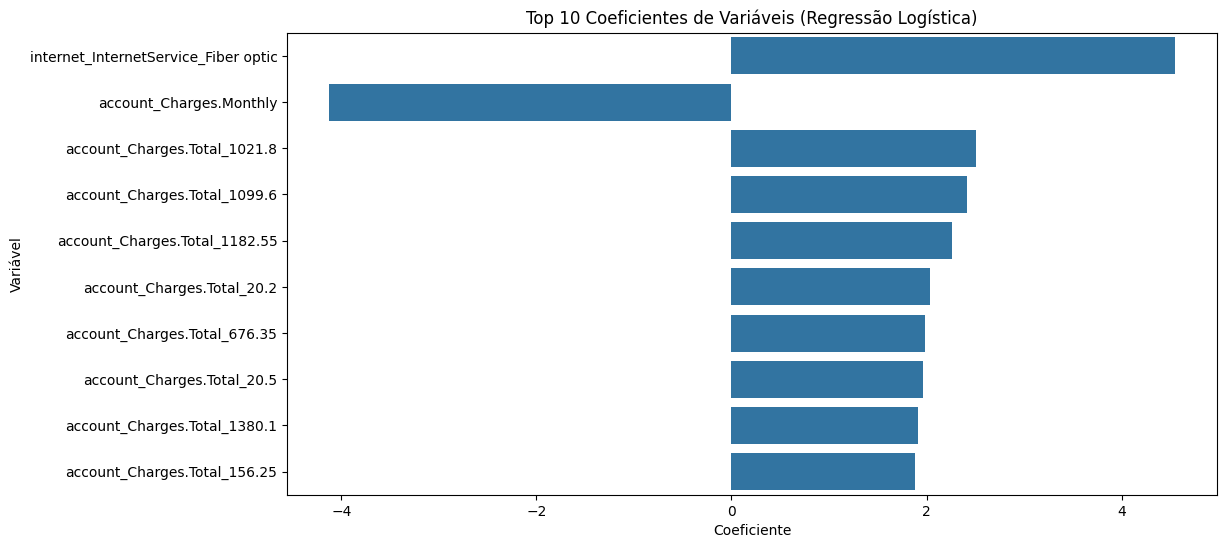


--- Random Forest: Importância das Variáveis ---
Top 10 Variáveis mais relevantes (Random Forest):
                                   Feature  Importance
1                          customer_tenure    0.113849
2                  account_Charges.Monthly    0.082741
27  account_PaymentMethod_Electronic check    0.054513
24               account_Contract_Two year    0.031816
25            account_PaperlessBilling_Yes    0.031661
9     internet_InternetService_Fiber optic    0.029839
23               account_Contract_One year    0.021461
12             internet_OnlineSecurity_Yes    0.015530
3                     customer_gender_Male    0.014623
18                internet_TechSupport_Yes    0.013990


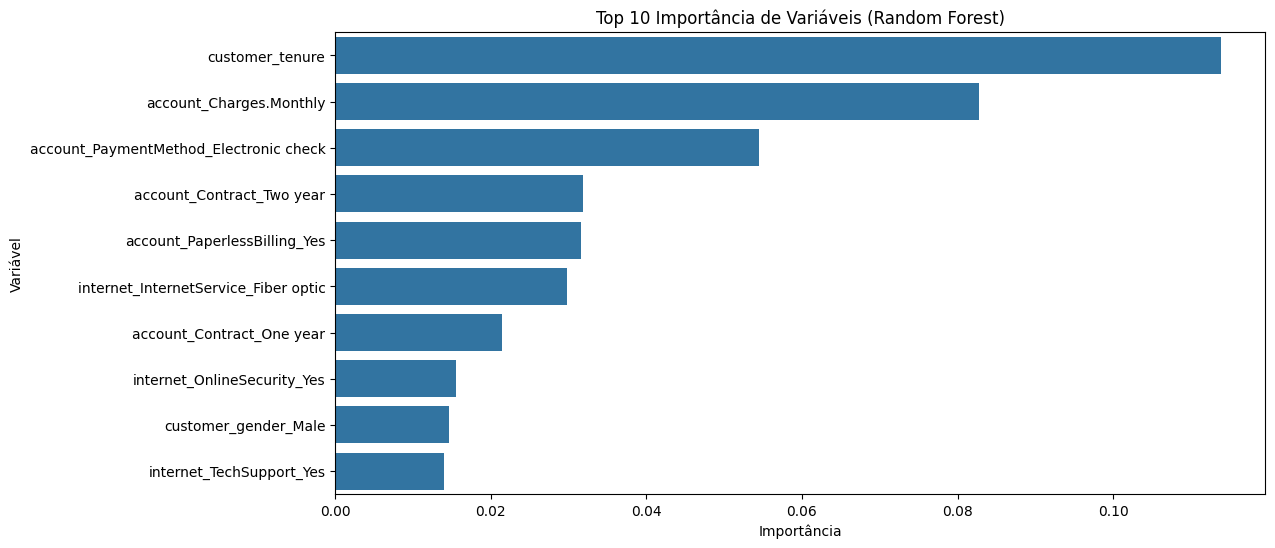


--------------------------------------------------
Conclusão da Análise de Variáveis
--------------------------------------------------
Ao comparar os resultados, podemos ver quais variáveis são consistentemente importantes em ambos os modelos ou quais são mais proeminentes em um modelo específico. Isso pode fornecer insights valiosos sobre os fatores que mais impulsionam a evasão de clientes.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--------------------------------------------------")
print("Análise de Variáveis Mais Relevantes para Previsão de Evasão")
print("--------------------------------------------------")

# --- 1. Análise para Regressão Logística (Coeficientes) ---
print("\n--- Regressão Logística: Coeficientes das Variáveis ---")
# Os coeficientes indicam a importância e a direção da relação com a variável alvo.
# Um coeficiente positivo indica que, conforme o valor da variável aumenta, a probabilidade de churn aumenta.
# Um coeficiente negativo indica que, conforme o valor da variável aumenta, a probabilidade de churn diminui.

log_reg_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# Ordenar por valor absoluto do coeficiente para ver as mais impactantes
log_reg_coefs['Abs_Coefficient'] = abs(log_reg_coefs['Coefficient'])
log_reg_coefs = log_reg_coefs.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

print("Top 10 Variáveis mais relevantes (Regressão Logística):")
print(log_reg_coefs.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x='Coefficient', y='Feature', data=log_reg_coefs.head(10))
plt.title('Top 10 Coeficientes de Variáveis (Regressão Logística)')
plt.xlabel('Coeficiente')
plt.ylabel('Variável')
plt.show()


# --- 2. Análise para Random Forest (Importância das Variáveis) ---
print("\n--- Random Forest: Importância das Variáveis ---")
# A importância da variável no Random Forest é calculada com base na redução de impureza (Gini impurity ou entropy)
# que cada variável traz em suas árvores. Valores maiores indicam maior importância.

rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': random_forest_model.feature_importances_
})

rf_importances = rf_importances.sort_values(by='Importance', ascending=False)

print("Top 10 Variáveis mais relevantes (Random Forest):")
print(rf_importances.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importances.head(10))
plt.title('Top 10 Importância de Variáveis (Random Forest)')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

print("\n--------------------------------------------------")
print("Conclusão da Análise de Variáveis")
print("--------------------------------------------------")
print("Ao comparar os resultados, podemos ver quais variáveis são consistentemente importantes em ambos os modelos ou quais são mais proeminentes em um modelo específico. Isso pode fornecer insights valiosos sobre os fatores que mais impulsionam a evasão de clientes.")


**Conclusão**

Principais Fatores que Aumentam a Probabilidade de Evasão (Coeficientes Positivos):

**Internet_InternetService_Fiber optic (4.55):** Clientes que utilizam serviço de internet de fibra óptica têm uma probabilidade significativamente maior de evadir. Isso pode indicar insatisfação com a qualidade do serviço, preço, ou ofertas de concorrentes mais atraentes para este tipo de conexão.  **Account_Charges.Total_1021.8 (2.51)**, **Account_Charges.Total_1099.6 (2.42)**, **Account_Charges.Total_1182.55 (2.26)** e outros valores específicos de account_Charges.Total: Vários valores específicos da coluna account_Charges.Total (que provavelmente representam categorias de valores totais de cobrança, já que a correlação foi feita com dummies) mostram uma alta correlação positiva. Isso sugere que clientes com contas totais mais altas (especialmente em certos patamares) são mais propensos a sair. Pode estar relacionado à percepção de custo-benefício ou a uma insatisfação geral com os gastos acumulados.

**Principais Fatores que Diminuem a Probabilidade de Evasão (Coeficientes Negativos):**

**Account_Charges.Monthly (-4.12):** Embora pareça contraintuitivo à primeira vista (dado que 'Charges.Total' tem coeficientes positivos), um coeficiente negativo para 'Charges.Monthly' pode indicar que clientes com cobranças mensais mais baixas são menos propensos a evadir. Ou, e mais provavelmente, é um artefato da alta cardinalidade de 'account_Charges.Total' e a forma como as dummies são interpretadas na regressão logística quando há multicolinearidade ou alta correlação entre as features. Precisaria de uma análise mais aprofundada para desvendar a interação exata entre Monthly Charges e Total Charges e churn.

**Em Resumo:**

Os resultados da Regressão Logística sugerem que o tipo de serviço de internet (fibra óptica) e os valores totais cobrados na conta são os fatores mais fortes que impulsionam a evasão, enquanto as cobranças mensais parecem ter uma relação inversa (mas com nuances a serem exploradas). Isso indica que a gestão de custos e a qualidade do serviço de internet são áreas críticas para focar nas estratégias de retenção.

Como estratégias de retenção, sugere-se:

**1. Para Clientes com Serviço de Internet Fibra Óptica:**

**Monitoramento da Satisfação:** Implementar pesquisas de satisfação regulares e focadas especificamente em usuários de fibra óptica para identificar pontos de insatisfação com a qualidade, velocidade ou suporte. Realizar follow-ups proativos.

**Reforço de Valor:** Comunicar ativamente os benefícios e o valor agregado do serviço de fibra óptica. Isso pode incluir demonstrações de performance, dicas para otimizar o uso e informações sobre as tecnologias por trás do serviço.
Ofertas Competitivas: Avaliar a concorrência no segmento de fibra óptica e ajustar preços ou oferecer pacotes de valor para manter a competitividade, especialmente para clientes com maior probabilidade de evasão.

**2. Para Clientes com Baixo Tempo de Permanência (customer_tenure):**

**Programa de Boas-Vindas Aprimorado:** Criar um programa de onboarding robusto nos primeiros 3 a 6 meses, com comunicações personalizadas, suporte prioritário e ofertas exclusivas para garantir uma experiência positiva inicial.

**Check-ins Proativos:** Contatos periódicos (e-mail, SMS, ligação) para verificar a satisfação do cliente, oferecer ajuda e resolver quaisquer problemas antes que eles se tornem motivos para churn.
Incentivos Iniciais: Oferecer descontos, brindes ou acesso a serviços premium por um período limitado para incentivar a permanência e a fidelização.
